In [37]:
#Importing the Env
from dotenv import load_dotenv
load_dotenv()

True

In [38]:
#Importing the Agents Libs
from typing import TypedDict,List,Annotated
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,END
from IPython.display import Image, display
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [39]:
#Creating a memory saver
memory=MemorySaver()

In [40]:
#Defining the State of the Agent

class agentstate(TypedDict):
    task:str
    result:str
    next_agent:str
    messages:Annotated[list,add_messages]

In [41]:
#Importing the LLM

llm=ChatGroq(
    model="llama-3.3-70b-versatile", 
)

In [42]:
#Defining the Manger Agent

def manager_agent(state):
    query=state["messages"]
    prompt = f"""
    You are a software house manager.
    
    
    Available developers:
    
    1 Web Developer → builds websites and web apps
    2 Chatbot Developer → builds chatbots
    3 Agentic AI Developer → builds autonomous AI systems

    If the message is just conversation (greeting, question, news, casual talk),
    respond with: conversation
    
    If the request does NOT match these categories,
    respond with: unknown
    
    User request:
    {query}
    
    Respond ONLY with:
    web
    chatbot
    agentic
    unknown
    conversation
    """

    response=llm.invoke(prompt)

    state["next_agent"]=response.content.strip().lower()
    return state

In [43]:
def web_agent(state):
    query=state["messages"]
    prompt = f"""
    You are a professional web developer.

    User request:
    {query}

    Provide a development plan.
    """
    response=llm.invoke(prompt)
    state["result"]=response.content
    return state

In [44]:
def chatbot_agent(state):
    query=state["messages"]
    prompt = f"""
    You are a chatbot developer.

    User request:
    {query}

    Provide chatbot development strategy.
    """
    response=llm.invoke(prompt)
    state["result"]=response.content
    return state

In [45]:
def agentic_agent(state):
    query=state["messages"]
    prompt = f"""
    You are an expert in agentic AI systems.

    User request:
    {query}

    Provide an agent architecture.
    """

    response=llm.invoke(prompt)
    state["result"]=response.content
    return state

In [46]:
def ask_user_agent(state):
    state["result"] = """
This request does not match the available developers.

Available services:
• Web Development
• Chatbot Development
• Agentic AI Systems

Please clarify your request.
"""

    return state

In [ ]:
def conversational_agent(state):
    messages=state["messages"]
    prompt=f"""You are a conversation handler for a software house AI system.

Your role is ONLY to handle short casual conversation like greetings.

You must NOT answer general knowledge questions.

if user as tech related questions it must be limited to
- web development
- chatbot development
- agentic AI development

If the user asks something unrelated to:
- web development
- chatbot development
- agentic AI development

politely tell the user that this system only supports software development related queries.

Keep responses short.
"""
    response=llm.invoke([prompt]+messages)
    state["result"]=response.content
    return state

In [48]:
builder=StateGraph(agentstate)
builder.add_node("manager",manager_agent)
builder.add_node("web",web_agent)
builder.add_node("chatbot",chatbot_agent)
builder.add_node("agentic",agentic_agent)
builder.add_node("ask_user",ask_user_agent)
builder.add_node("conversation",conversational_agent)
builder.set_entry_point("manager")


#Defining Routing
def router(state):
    return state["next_agent"]

builder.add_conditional_edges(
    "manager",
    router,
    {
        "web": "web",
        "chatbot": "chatbot",
        "agentic": "agentic",
        "unknown":"ask_user",
        "conversation":"conversation"
    }
)

builder.add_edge("web",END)
builder.add_edge("chatbot",END)
builder.add_edge("agentic",END)
builder.add_edge("ask_user",END)
builder.add_edge("conversation",END)

graph=builder.compile(checkpointer=memory)

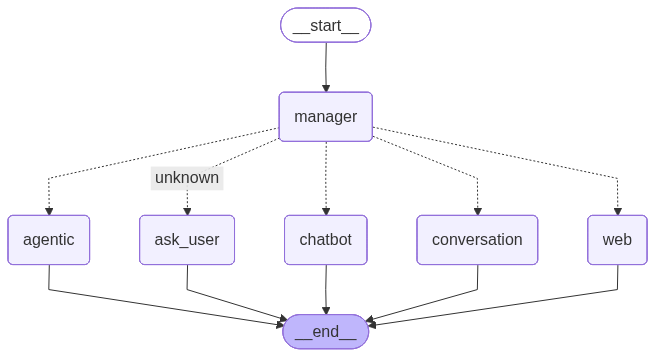

In [49]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
#Making an unique thread id
config={"configurable":{"thread_id":"user_123"}}

In [51]:
query = input("Ask your question: ") 
result = graph.invoke({"messages": [query]},config)
print("\nFinal Answer:\n")
print(result["result"])


Final Answer:

**Mobile App Development Plan**

Based on your request to build a mobile app, I'll outline a comprehensive development plan to help you achieve your goal. Please find the details below:

### Project Overview

* **App Type**: We will determine the type of app you want to build (e.g., gaming, productivity, social media, e-commerce, etc.)
* **Target Audience**: Identify the primary audience for your app
* **Platforms**: Decide on the platforms you want to support (iOS, Android, or both)

### Development Phases

1. **Discovery Phase** (2-5 days)
	* Discuss and refine your app idea
	* Identify the app's core features and functionalities
	* Determine the technical requirements and feasibility
	* Create a rough wireframe and prototype
2. **Design Phase** (5-10 days)
	* Develop a visually appealing and user-friendly design concept
	* Create high-fidelity wireframes and mockups
	* Design the app's user interface (UI) and user experience (UX)
3. **Development Phase** (20-40 days)